<b>Введение к занятию

<b>Цели занятия</b>


Визуализировать работу механизма self-attention, чтобы понять, как модель «видит» и обрабатывает текст.

Разобраться в различиях архитектур BERT, GPT и T5, а также в том, для каких задач каждая из них подходит лучше всего.
the animal didnät cross the street becouse it was too tired


<b>Краткое содержание</b>


Основные техники визуализации внимания (attention).

Особенности архитектур: BERT (Masked Language Modeling), GPT (Autoregressive), T5 (Encoder-Decoder).

Анализ внутренних слоёв моделей с помощью тепловых карт внимания (Attention heatmaps).

Практические примеры, показывающие, как визуализация помогает улучшить понимание работы модели.

<b>Техники визуализации Attention</b>


<b>Attention heatmaps (тепловые карты внимания)</b>

Самая популярная техника. Отображает веса внимания в виде матрицы, где по осям — токены входного и выходного текста.

Яркие участки показывают, на какие слова модель «смотрит» при генерации каждого токена.

    
<b>Graph-based visualization (графовые визуализации)</b>

    
Представляет связи внимания как граф, где узлы — токены, а ребра — веса внимания.

Помогает увидеть, как информация распространяется между словами.


<b>Attention rollout</b>


Техника для агрегирования внимания по всем слоям модели, чтобы понять общую схему «взгляда» модели на вход.

Позволяет получить суммарную карту внимания.



<b>Attention flow tracing (трассировка потока внимания)</b>


Прослеживает путь внимания по слоям и головам, чтобы выявить, как и где именно модель сосредотачивается.

Полезно для изучения особенностей работы разных голов (heads) внимания.


<b>Saliency maps (карты значимости)</b>


Показывают, какие токены наиболее сильно влияют на итоговое предсказание, основанные на градиентах.

Могут дополнять информацию от attention, выявляя важность токенов.


    
<b>Layer-wise visualization</b>

Визуализация внимания по отдельным слоям и головам, чтобы увидеть различия в фокусе модели на разных уровнях.

Помогает понять эволюцию признаков внутри модели.

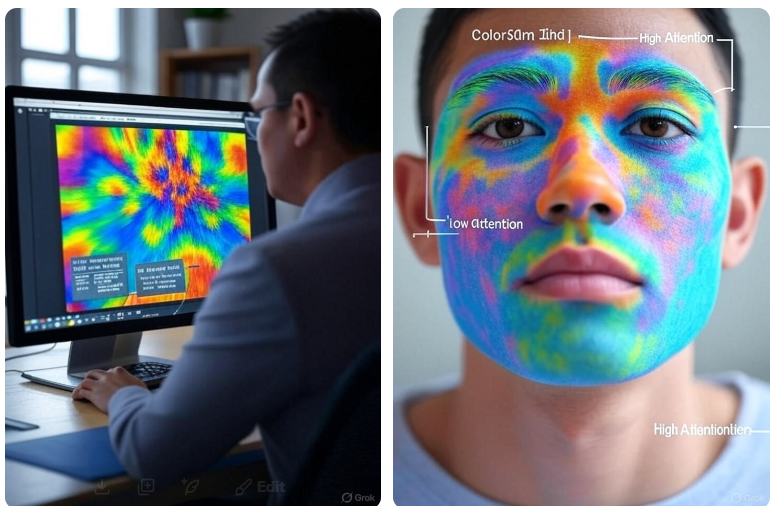

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


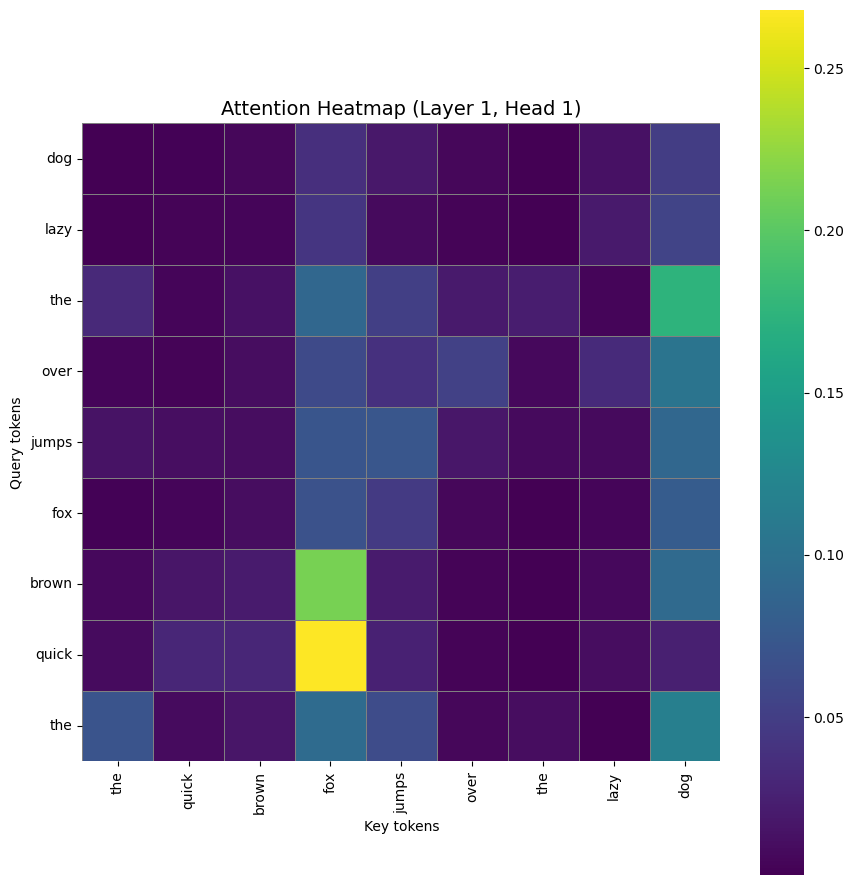

In [1]:
#Attention heatmaps (тепловые карты внимания)
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns

# Инициализация модели и токенизатора
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)

text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')

# Получаем выход и attention веса
outputs = model(**inputs)
attentions = outputs.attentions  # tuple из слоёв: (num_layers, batch, num_heads, seq_len, seq_len)

layer_idx=10
head_idx=6

# Выбираем первый слой и первую голову внимания
attention = attentions[layer_idx][0][head_idx].detach().numpy()

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
assert attention.shape[0] == len(tokens), f"mismatch: attention {attention.shape}, tokens {len(tokens)}"

tokens = tokens[1:-1]
attention = attention[1:-1, 1:-1]

num_tokens = len(tokens)
fig_size = num_tokens


plt.figure(figsize=(fig_size, fig_size))
ax = sns.heatmap(
    attention,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap='viridis',
    square=True,
    cbar=True,
    linewidths=0.5,
    linecolor='gray'

)

ax.invert_yaxis()

#plt.figure(figsize=(8, 6))
#sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title('Attention Heatmap (Layer 1, Head 1)', fontsize=14)
plt.xlabel('Key tokens')
plt.ylabel('Query tokens')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


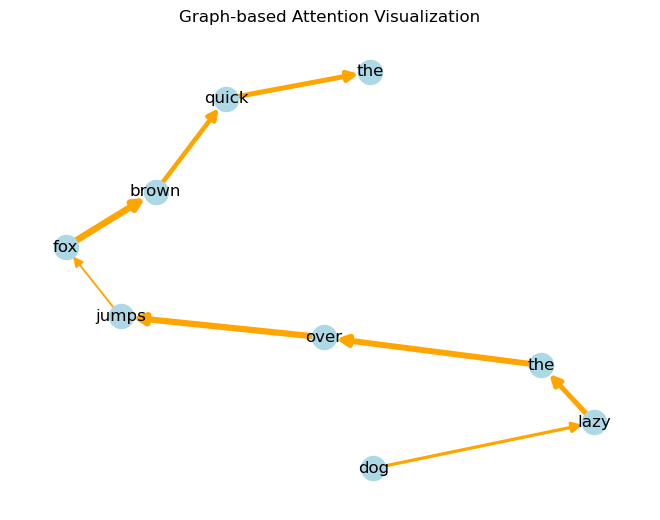

In [11]:
#Graph-based visualization (визуализация графа внимания)
import networkx as nx

# Построим граф из attention (взяли тот же слой и голову)
G = nx.DiGraph()

# Добавим вершины — токены
for i, token in enumerate(tokens):
    G.add_node(i, label=token)

# Добавим ребра с весами attention > 0.1 (чтобы граф не был перегружен)
threshold = 0.1
for i in range(attention.shape[0]):
    for j in range(attention.shape[1]):
        if attention[i, j] > threshold:
            G.add_edge(i, j, weight=attention[i, j])

pos = nx.spring_layout(G)
edge_weights = [G[u][v]['weight']*5 for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, labels={i:t for i,t in enumerate(tokens)}, 
        node_color='lightblue', edge_color='orange', width=edge_weights, arrowsize=15)
plt.title("Graph-based Attention Visualization")
plt.show()


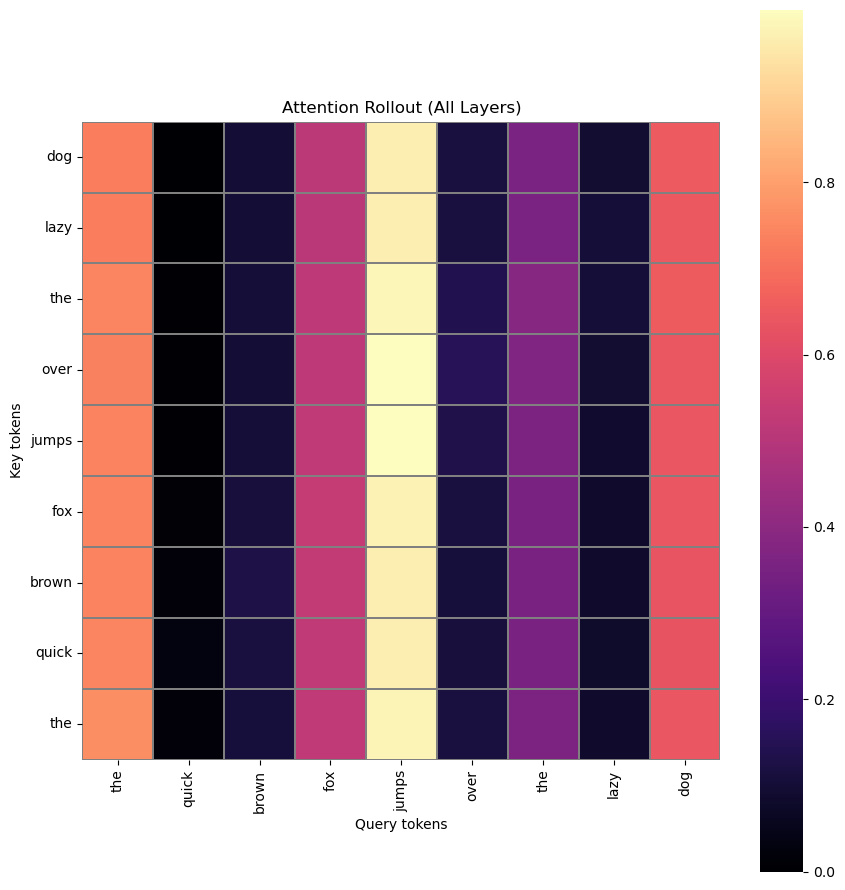

In [19]:
#3. Attention rollout (агрегация по слоям)
import numpy as np

# Функция rollout - сумма внимания по всем слоям с усреднением по головам
def attention_rollout(attentions):
    # attentions: tuple из всех слоёв (num_layers, batch, num_heads, seq_len, seq_len)
    num_layers = len(attentions)
    rollout = np.eye(attentions[0].shape[-1])
    for layer_attention in attentions:
        # Усредняем по головам
        avg_attention = layer_attention[0].mean(axis=0).detach().numpy()

        avg_attention = avg_attention + np.eye(avg_attention.shape[0])

        avg_attention = avg_attention / avg_attention.sum(axis=-1, keepdims=True)
        
        rollout = np.matmul(rollout, avg_attention)
    return rollout

rollout_map = attention_rollout(attentions)

rollout_map = rollout_map[1:-1, 1:-1]
tokens_trimmed = tokens
rollout_map_norm = (rollout_map - rollout_map.min())/ (rollout_map.max() - rollout_map.min() + 1e-9)



rollout_map_norm_T = rollout_map_norm#.T


plt.figure(figsize=(len(tokens_trimmed),len(tokens_trimmed)))

ax = sns.heatmap(rollout_map_norm_T, 
                 xticklabels=tokens_trimmed, 
                 yticklabels=tokens_trimmed, 
                 cmap='magma',
                 square = True,
                 linewidths=0.3,
                 linecolor='gray',
                 cbar=True)

ax.invert_yaxis()
plt.xticks(rotation=90)
plt.yticks(rotation=0)

#sns.heatmap(rollout_map_norm, xticklabels=tokens, yticklabels=tokens, cmap='magma')
plt.title('Attention Rollout (All Layers)')
plt.xlabel('Query tokens')
plt.ylabel('Key tokens')
plt.tight_layout()
plt.show()


IndexError: index 2 is out of bounds for axis 0 with size 2

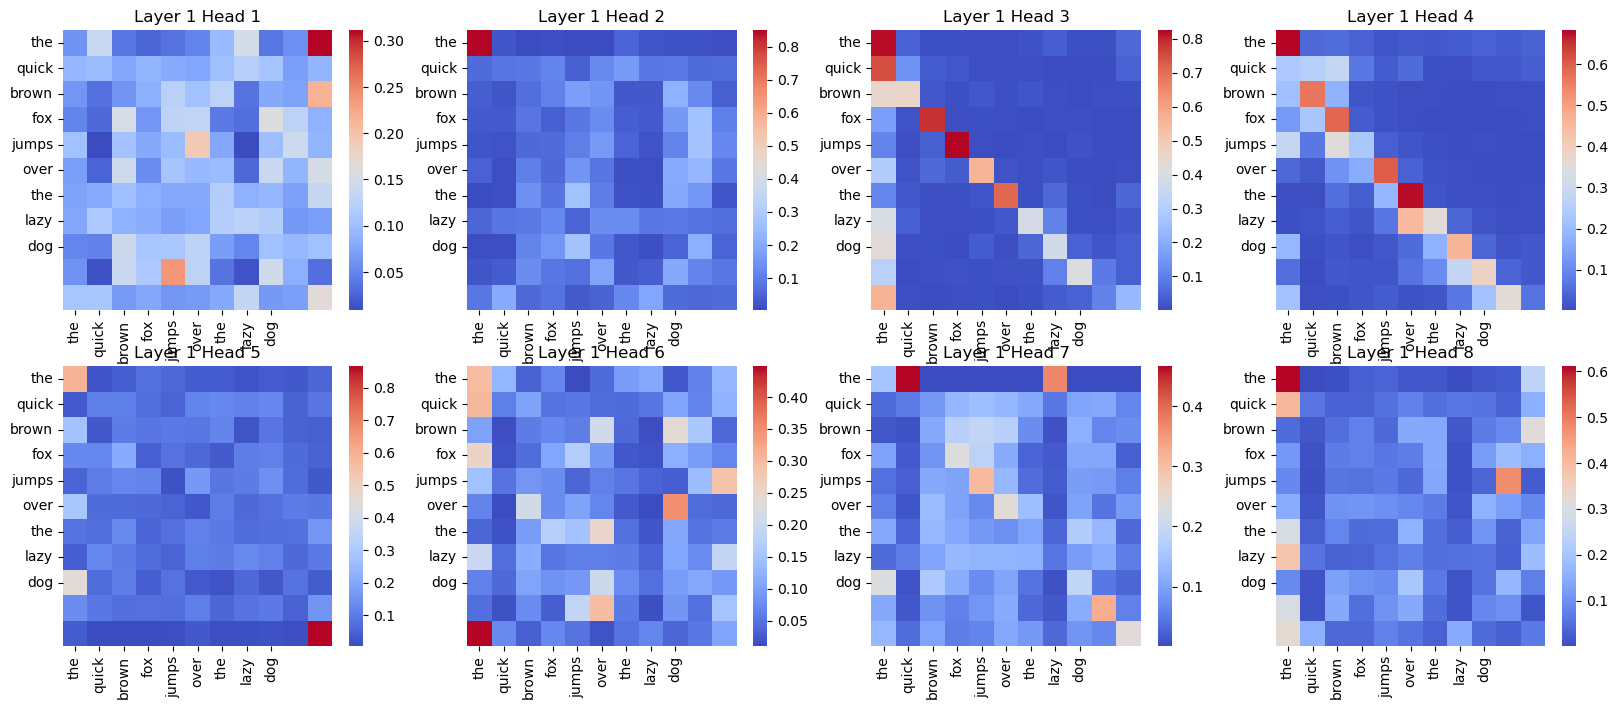

In [7]:
#4. Attention flow tracing (простой трассинг внимания по слоям и головам)
# Выведем тепловые карты внимания для всех голов первого слоя

fig, axs = plt.subplots(2, 4, figsize=(20, 8))
heads = attentions[0][0].shape[0]

for i in range(heads):
    ax = axs[i//4, i%4]
    sns.heatmap(attentions[0][0][i].detach().numpy(), xticklabels=tokens, yticklabels=tokens, ax=ax, cmap='coolwarm')
    ax.set_title(f'Layer 1 Head {i+1}')
plt.tight_layout()
plt.show()


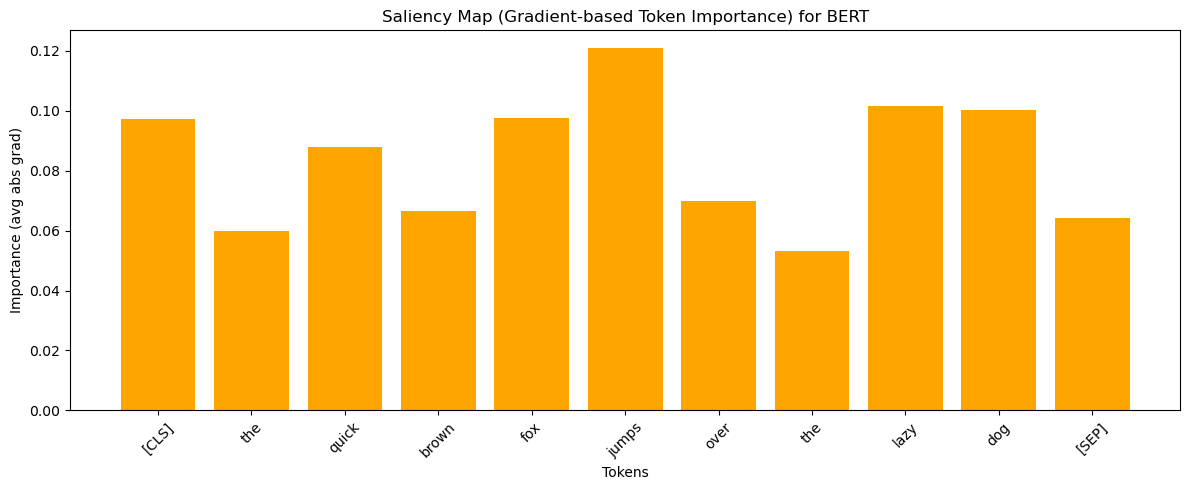

In [25]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib inline  # Раскомментируй, если ты в Jupyter Notebook

# Инициализация токенизатора и модели (BERT base)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

# Текст для анализа
text = "The quick brown fox jumps over the lazy dog"

# Токенизация
inputs = tokenizer(text, return_tensors='pt')
input_ids = inputs['input_ids']

# Получаем слой эмбеддингов модели
embedding_layer = model.get_input_embeddings()

# Получаем эмбеддинги входных токенов
embeddings = embedding_layer(input_ids)
embeddings.requires_grad_()     # Включаем подсчет градиентов
embeddings.retain_grad()        # Сохраняем градиенты для не-листового тензора

# Прямой проход по модели с входными эмбеддингами
outputs = model(inputs_embeds=embeddings)

# Используем сумму по последнему слою CLS-токена (первый токен)
cls_token_embedding = outputs.last_hidden_state[:, 0, :]
score = cls_token_embedding.sum()
score.backward()  # Обратное распространение ошибки

# Получаем градиенты по эмбеддингам
grads = embeddings.grad.abs().squeeze(0)  # shape (seq_len, embedding_dim)

# Усредняем по размерности эмбеддинга, чтобы получить значение значимости для каждого токена
token_importance = grads.mean(dim=1).detach().cpu().numpy()

# Получаем токены для отображения
tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())

# Визуализация
plt.figure(figsize=(12, 5))
plt.bar(range(len(tokens)), token_importance, color='orange')
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.xlabel("Tokens")
plt.ylabel("Importance (avg abs grad)")
plt.title("Saliency Map (Gradient-based Token Importance) for BERT")
plt.tight_layout()
plt.show()


<b>BERT (Masked Language Modeling)

In [ ]:
Как работает: во входном тексте случайные слова заменяются на [MASK], и модель учится предсказывать эти замаскированные слова, используя контекст слева и справа.

Пример:

Вход: The quick brown [MASK] jumps over the lazy dog.
Задача модели: предсказать, что стоит вместо [MASK], например, "fox".
Пример использования в коде (псевдокод):

input_text = "The quick brown [MASK] jumps over the lazy dog."
# Модель BERT получает этот текст с [MASK]
# Выход: предсказание слова "fox" на месте [MASK]

<b>GPT (Autoregressive)

In [ ]:
Как работает: модель предсказывает следующий токен, глядя только на предыдущие (слева) токены. Генерация текста идёт слева направо.

Пример:

Вход: The quick brown
Модель предсказывает: "fox"
Затем: The quick brown fox
Модель предсказывает: "jumps"
и так далее...
Пример использования в коде (псевдокод):

input_text = "The quick brown"
# Модель GPT генерирует слово "fox"
# Затем подставляет "fox" и генерирует следующее слово "jumps"

<b>T5 (Encoder-Decoder)

Как работает: сначала encoder кодирует входной текст, затем decoder генерирует выходной текст. Все задачи — в формате "текст на входе → текст на выходе".

Пример:

Вход: "translate English to German: That is good."
Выход: "Das ist gut."
Пример использования в коде (псевдокод):

input_text = "summarize: The quick brown fox jumps over the lazy dog."
# Модель T5 возвращает краткое содержание, например: "A fox jumps over a dog."

<b>Что такое внимание (Attention) в трансформерах?

Внимание — это механизм, который помогает модели решать, на какие части входного текста ей стоит обращать больше внимания при обработке каждого слова.

Представь, что ты читаешь предложение и пытаешься понять значение конкретного слова. Ты не просто смотришь на это слово, а обращаешь внимание и на соседние слова, которые важны для понимания.

Трансформер имитирует это с помощью чисел — веса внимания (attention weights), которые показывают, сколько внимания модель уделяет каждому слову относительно текущего.

<b>Внутренние слои и головы внимания

В трансформере несколько слоёв (layers). Каждый слой — это уровень обработки текста.

В каждом слое несколько "голов" внимания (attention heads), которые учатся обращать внимание на разные аспекты текста параллельно.

Каждая голова генерирует матрицу внимания: для каждого слова показывает, на какие другие слова оно смотрит и насколько сильно.

<b>Что такое Attention-тепловая карта?

In [ ]:
Это визуальное представление матрицы внимания в виде цветной таблицы (heatmap).

По оси X — все слова исходного текста.

По оси Y — слова, для которых вычисляется внимание.

Цвет в каждой ячейке показывает степень внимания: чем ярче/темнее цвет, тем сильнее внимание.

<b>Зачем смотреть на Attention-тепловые карты?

In [ ]:
Чтобы понять, как модель "видит" текст: какие слова она считает важными для понимания других слов.

Можно увидеть, например, что для слова "jumps" модель обращает много внимания на "fox" и "quick", потому что они связаны по смыслу.

Это помогает диагностировать и интерпретировать поведение модели.

<b>Как выглядит процесс анализа?

In [ ]:
Получаем attention weights из модели (если у модели включена опция output_attentions=True).

Выбираем слой и голову, которую хотим проанализировать.

Визуализируем матрицу внимания в виде тепловой карты.

Смотрим, какие слова выделены ярче для данного токена — это и есть важные для модели связи.

In [ ]:
Пример объяснения на простом предложении:
Текст:
The quick brown fox jumps over the lazy dog.

Для слова "jumps" внимание может быть сильно направлено на "fox" (кто прыгает).

Для слова "lazy" внимание — на "dog" (ленивая собака).

Для слова "The" внимание может быть более равномерным, т.к. это служебное слово.

In [ ]:
Почему по слоям?
В нижних слоях модель смотрит на локальные связи (ближайшие слова).

В средних и верхних слоях — на более глобальные, контекстные связи.

Анализ по слоям помогает понять, как модель постепенно строит сложное понимание текста.



<b>Практические кейсы улучшения понимания модели через визуализацию Attention

1. Проверка корректности внимания для конкретного слова
Задача: Убедиться, что модель действительно обращает внимание на релевантные слова при анализе предложения.

    
Например, для слова "jumps" в предложении "The quick brown fox jumps over the lazy dog" модель должна выделять "fox" — субъект действия.

    
2. Выявление ошибок модели
Задача: Если модель уделяет слишком много внимания нерелевантным словам, это может объяснить плохое качество предсказаний.


Визуализация помогает понять, почему модель ошибается, и какие слова вызывают путаницу.

3. Сравнение внимания между слоями и головами
Задача: Понять, на каких слоях и головах модель лучше улавливает смысловые связи, а где — шум.

    
Можно решить, какие слои или головы стоит фиксировать, какие — дообучать.

    
4. Объяснение предсказаний модели пользователям
Задача: В задачах доверия и объяснимости (Explainable AI) показать, почему модель сделала именно такое предсказание.

Визуализация внимания — отличный способ показать, что модель "смотрит" на важные слова.

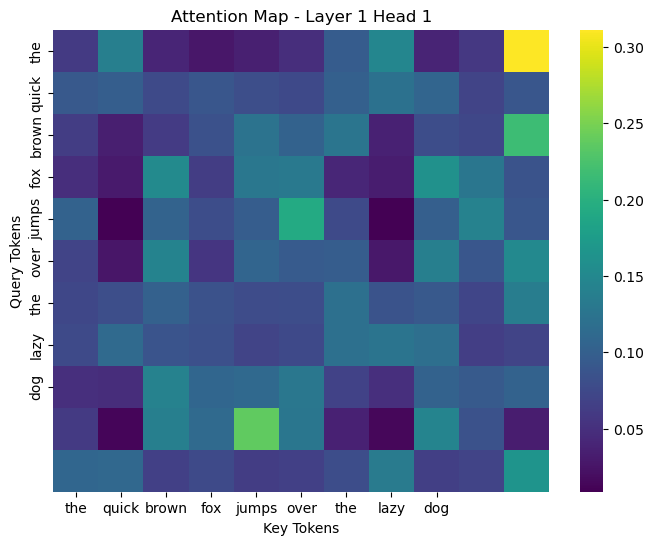

In [11]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns

# Инициализация
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
model.eval()

text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')

# Прогон через модель с возвратом attention
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # список с attention из каждого слоя

tokens = tokenizer.tokenize(text)

# Визуализация внимания для первого слоя и первой головы
layer = 0
head = 0

attention_matrix = attentions[layer][0, head].detach().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title(f'Attention Map - Layer {layer+1} Head {head+1}')
plt.xlabel('Key Tokens')
plt.ylabel('Query Tokens')
plt.show()


In [ ]:
Как это помогает:
Мы видим, на какие токены модель обращает внимание при обработке каждого токена.

Если, например, для токена "jumps" ярко выделяется "fox" — модель связывает действие и субъект правильно.

Если внимание разбросано или акцент на ненужных словах — можно сделать вывод о слабых местах.

<b>Еще примеры, с ответом на вопрос ЗАЧЕМ? в понятной форме

<b>Визуализация self-attention (BERT) — зачем нужны веса внимания?


Зачем это нужно?
Веса внимания показывают, какие слова модель считает важными при обработке каждого слова. Это помогает понять внутреннюю логику модели.

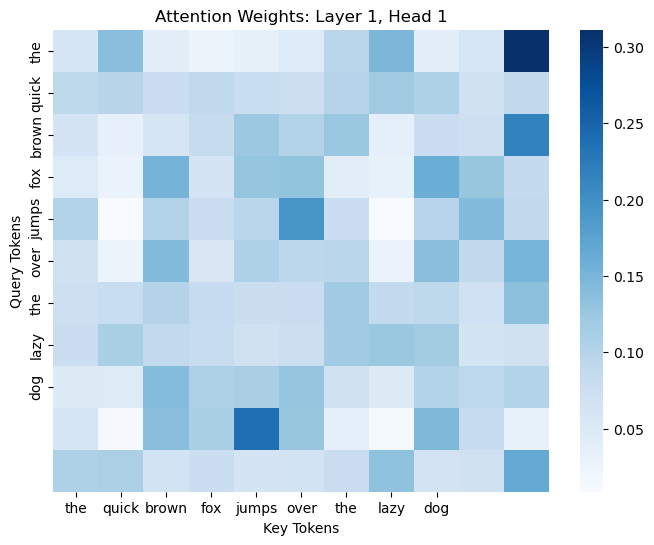

In [12]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем токенизатор и модель с возвратом attention
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
model.eval()

text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')

with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # список attention для каждого слоя

tokens = tokenizer.tokenize(text)

# Возьмем первый слой, первую голову
layer = 0
head = 0
attention_matrix = attentions[layer][0, head].cpu().numpy()

plt.figure(figsize=(8,6))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap='Blues')
plt.title(f'Attention Weights: Layer {layer+1}, Head {head+1}')
plt.xlabel('Key Tokens')
plt.ylabel('Query Tokens')
plt.show()


<b>Saliency maps — почему градиенты важны?


Зачем?
Градиенты показывают, как изменение каждого входного токена повлияет на выход модели. Это позволяет выделить, какие слова наиболее важны для конкретного предсказания.

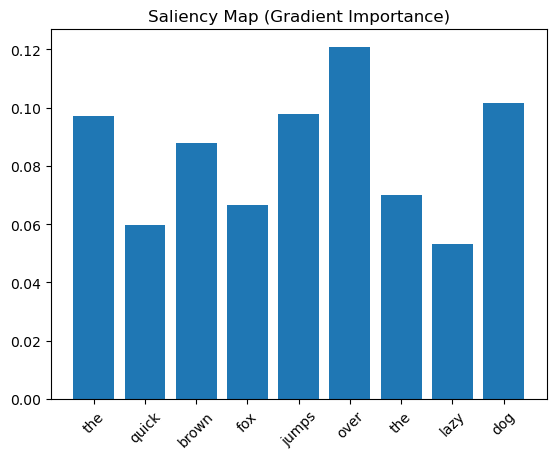

In [14]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import numpy as np

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')
input_ids = inputs['input_ids']

embedding_layer = model.get_input_embeddings()
embeddings = embedding_layer(input_ids)
embeddings.requires_grad_()
embeddings.retain_grad()  # <-- добавляем здесь

outputs = model(inputs_embeds=embeddings)
loss = outputs.last_hidden_state[:, 0, :].sum()  # суммируем CLS токен
loss.backward()

grads = embeddings.grad.abs().squeeze(0)
token_importance = grads.mean(dim=1).detach().cpu().numpy()
tokens = tokenizer.tokenize(text)

plt.bar(range(len(tokens)), token_importance[:len(tokens)])
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.title('Saliency Map (Gradient Importance)')
plt.show()


<b>Отличия BERT, GPT и T5 — и зачем это знать?


BERT — понимает контекст слева и справа (Masked LM). Используется для задач понимания текста (классификация, QA).

GPT — генерирует текст слева направо (Autoregressive). Отлично для генерации.

T5 — комбинирует энкодер и декодер, универсальная модель для перевода, суммаризации и др

In [18]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

text = "The quick brown fox"
inputs = tokenizer(text, return_tensors='pt')
outputs = model.generate(**inputs, max_length=20)

print(tokenizer.decode(outputs[0]))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The quick brown foxes are a great way to get a little bit of a kick out of your


<b>Layer-wise attention — зачем смотреть все головы и слои?


Зачем?
Каждая голова и слой изучает разные связи и типы информации. Анализ помогает понять, где модель концентрируется и выявить проблемы.

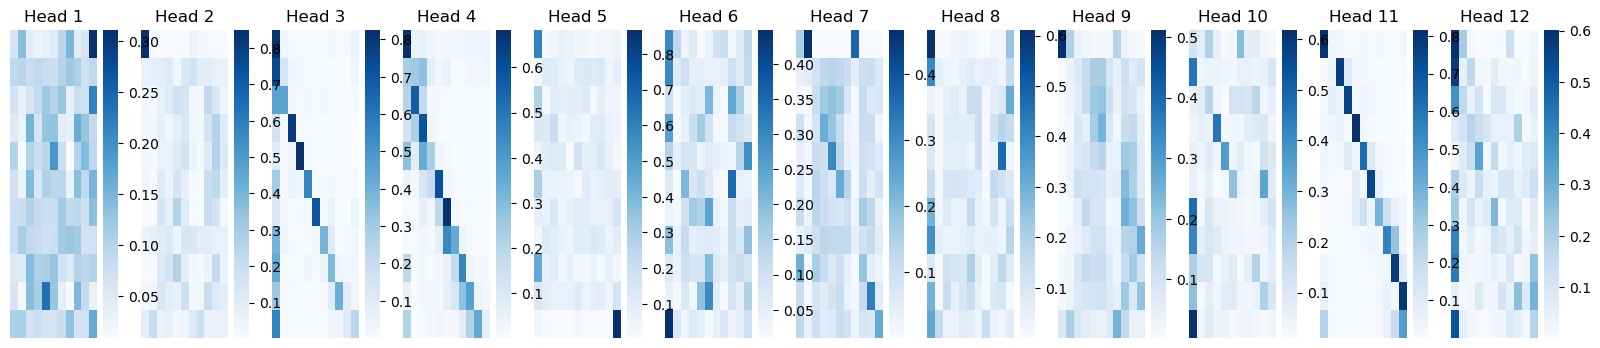

In [19]:
num_heads = attentions[0].shape[1]
fig, axs = plt.subplots(1, num_heads, figsize=(20, 4))

for head in range(num_heads):
    sns.heatmap(attentions[0][0, head].cpu().numpy(), xticklabels=tokens, yticklabels=tokens, ax=axs[head], cmap='Blues')
    axs[head].set_title(f'Head {head+1}')
    axs[head].axis('off')

plt.show()
